# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [17]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF_TOKEN loaded:", bool(HF_TOKEN))

HF_TOKEN loaded: True


In [18]:
import duckdb

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

con.execute("""
    CREATE OR REPLACE SECRET hf_token (
        TYPE huggingface,
        TOKEN ?
    )
""", [HF_TOKEN])

print("✅ DuckDB is authenticated with Hugging Face")

✅ DuckDB is authenticated with Hugging Face


In [19]:
warehouse = "hf://datasets/FlyRank/internship-warehouse"

performance_path = (
    f"{warehouse}/fact_content_daily_performance/"
    f"month=2026-03/**/*.parquet"
)

print(performance_path)

hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/**/*.parquet


In [20]:
test = con.sql(f"""
    SELECT
        COUNT(*) AS n,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date
    FROM read_parquet('{performance_path}')
""").df()

display(test)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n,min_date,max_date
0,9841378,2026-03-01,2026-03-31


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

The main traffic metrics are heavy-tailed: a relatively small number of observations have much larger impressions and clicks than the typical observation. I therefore use bucketed comparisons and denominator-weighted rates in the signal tests rather than relying on raw means or Pearson correlation.

In [21]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Check warehouse date range first
panel_check = con.sql(f"""
    SELECT
        COUNT(*) AS n,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date
    FROM read_parquet('{performance_path}')
""").df()

display(panel_check)

# Check the schema
schema_df = con.sql(f"""
    DESCRIBE SELECT *
    FROM read_parquet('{performance_path}')
""").df()

print("Available columns:")
print(schema_df["column_name"].tolist())

,n,min_date,max_date
0,9841378,2026-03-01,2026-03-31


Available columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


In [22]:
# ============================================================
# ML-06 — SECTION 1: DISTRIBUTION SUMMARY
# Correct warehouse fields
# ============================================================

distribution_df = con.sql(f"""
    WITH base AS (
        SELECT
            gsc_impressions,
            gsc_clicks,
            gsc_avg_position,

            CASE
                WHEN gsc_impressions > 0
                THEN 100.0 * gsc_clicks / gsc_impressions
                ELSE NULL
            END AS row_ctr_pct

        FROM read_parquet('{performance_path}')

        WHERE gsc_data_available = TRUE
          AND gsc_impressions IS NOT NULL
          AND gsc_clicks IS NOT NULL
    )

    SELECT
        COUNT(*) AS n,

        MIN(gsc_impressions) AS impressions_min,
        quantile_cont(gsc_impressions, 0.25) AS impressions_p25,
        quantile_cont(gsc_impressions, 0.50) AS impressions_median,
        quantile_cont(gsc_impressions, 0.75) AS impressions_p75,
        quantile_cont(gsc_impressions, 0.95) AS impressions_p95,
        MAX(gsc_impressions) AS impressions_max,

        MIN(gsc_clicks) AS clicks_min,
        quantile_cont(gsc_clicks, 0.25) AS clicks_p25,
        quantile_cont(gsc_clicks, 0.50) AS clicks_median,
        quantile_cont(gsc_clicks, 0.75) AS clicks_p75,
        quantile_cont(gsc_clicks, 0.95) AS clicks_p95,
        MAX(gsc_clicks) AS clicks_max,

        quantile_cont(row_ctr_pct, 0.25) AS ctr_p25,
        quantile_cont(row_ctr_pct, 0.50) AS ctr_median,
        quantile_cont(row_ctr_pct, 0.75) AS ctr_p75,
        quantile_cont(row_ctr_pct, 0.95) AS ctr_p95,

        quantile_cont(
            CASE
                WHEN gsc_avg_position > 0
                THEN gsc_avg_position
                ELSE NULL
            END,
            0.25
        ) AS position_p25,

        quantile_cont(
            CASE
                WHEN gsc_avg_position > 0
                THEN gsc_avg_position
                ELSE NULL
            END,
            0.50
        ) AS position_median,

        quantile_cont(
            CASE
                WHEN gsc_avg_position > 0
                THEN gsc_avg_position
                ELSE NULL
            END,
            0.75
        ) AS position_p75,

        quantile_cont(
            CASE
                WHEN gsc_avg_position > 0
                THEN gsc_avg_position
                ELSE NULL
            END,
            0.95
        ) AS position_p95

    FROM base
""").df()

display(distribution_df.T)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,0
n,3.611061e+06
impressions_min,1.000000e+00
impressions_p25,4.000000e+00
impressions_median,1.600000e+01
impressions_p75,6.200000e+01
impressions_p95,3.350000e+02
impressions_max,4.008400e+04
clicks_min,0.000000e+00
clicks_p25,0.000000e+00
clicks_median,0.000000e+00


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sample size: 38995


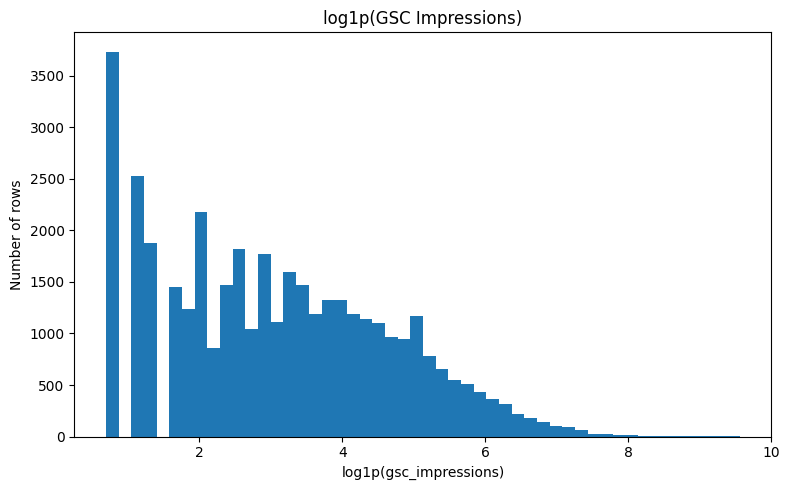

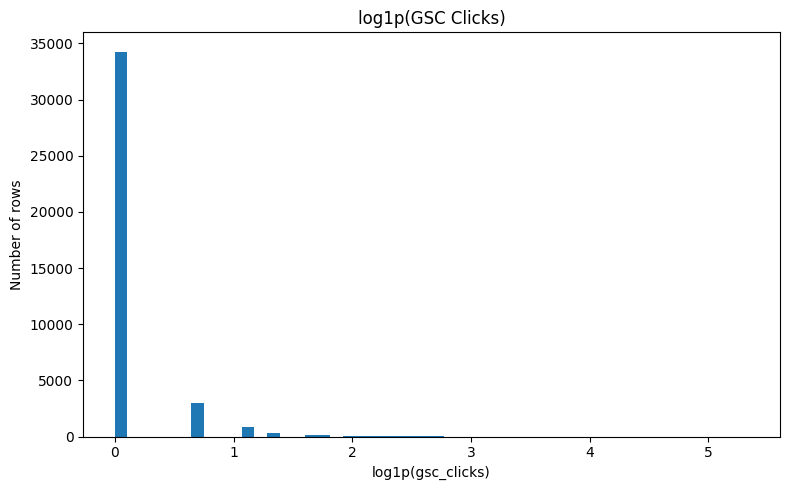

In [23]:
# ============================================================
# Heavy-tail inspection
# ============================================================

sample_df = con.sql(f"""
    SELECT
        gsc_impressions,
        gsc_clicks
    FROM read_parquet('{performance_path}')
    WHERE gsc_data_available = TRUE
      AND gsc_impressions >= 0
      AND gsc_clicks >= 0
    USING SAMPLE 100000
""").df()

print("Sample size:", len(sample_df))

# Impressions
plt.figure(figsize=(8, 5))
plt.hist(
    np.log1p(sample_df["gsc_impressions"]),
    bins=50
)
plt.title("log1p(GSC Impressions)")
plt.xlabel("log1p(gsc_impressions)")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

# Clicks
plt.figure(figsize=(8, 5))
plt.hist(
    np.log1p(sample_df["gsc_clicks"]),
    bins=50
)
plt.title("log1p(GSC Clicks)")
plt.xlabel("log1p(gsc_clicks)")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

I test three observed signals using bucketed comparisons. Each test shows the sample size for every bucket and applies the 50-row minimum before assigning a verdict. The tests use observed GSC fields only and do not use trend labels or future-window outcomes.

In [24]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# ------------------------------------------------------------
# SIGNAL TEST #1
# Claim: Higher search volume is associated with more clicks.
# ------------------------------------------------------------

print("=" * 70)
print("SIGNAL TEST #1 — IMPRESSIONS → CLICKS")
print("=" * 70)

signal1 = con.sql(f"""
    WITH base AS (
        SELECT
            gsc_impressions,
            gsc_clicks
        FROM read_parquet('{performance_path}')
        WHERE gsc_data_available = TRUE
          AND gsc_impressions IS NOT NULL
          AND gsc_clicks IS NOT NULL
          AND gsc_impressions >= 0
          AND gsc_clicks >= 0
    ),

    bucketed AS (
        SELECT
            CASE
                WHEN gsc_impressions = 0 THEN '0'
                WHEN gsc_impressions < 10 THEN '1-9'
                WHEN gsc_impressions < 100 THEN '10-99'
                WHEN gsc_impressions < 1000 THEN '100-999'
                WHEN gsc_impressions < 10000 THEN '1k-9.9k'
                ELSE '10k+'
            END AS impression_bucket,

            gsc_clicks

        FROM base
    )

    SELECT
        impression_bucket,
        COUNT(*) AS n,
        ROUND(quantile_cont(gsc_clicks, 0.50), 2) AS median_clicks,
        ROUND(AVG(gsc_clicks), 2) AS mean_clicks

    FROM bucketed

    GROUP BY impression_bucket

    ORDER BY
        CASE impression_bucket
            WHEN '0' THEN 1
            WHEN '1-9' THEN 2
            WHEN '10-99' THEN 3
            WHEN '100-999' THEN 4
            WHEN '1k-9.9k' THEN 5
            WHEN '10k+' THEN 6
        END
""").df()

display(signal1)

valid1 = signal1[signal1["n"] >= 50].copy()

print("\nSample-size check:")
print(
    f"{len(valid1)} of {len(signal1)} buckets meet the "
    "50-row minimum."
)

if len(valid1) < 2:
    verdict1 = "FALSE"
    reason1 = (
        "Insufficient data: fewer than two buckets meet the "
        "50-row sample-size floor."
    )
else:
    medians = valid1["median_clicks"].tolist()

    if all(
        medians[i] <= medians[i + 1]
        for i in range(len(medians) - 1)
    ):
        verdict1 = "CONFIRMED"
        reason1 = (
            "Median clicks increase consistently across the valid "
            "impression buckets."
        )

    elif all(
        medians[i] >= medians[i + 1]
        for i in range(len(medians) - 1)
    ):
        verdict1 = "OPPOSITE"
        reason1 = (
            "Median clicks decrease consistently across the valid "
            "impression buckets."
        )

    else:
        verdict1 = "MIXED"
        reason1 = (
            "Median clicks do not move consistently across the "
            "valid impression buckets."
        )

print(f"\nVerdict #1: {verdict1}")
print(reason1)


# ------------------------------------------------------------
# SIGNAL TEST #2
# Claim: Better search position is associated with higher CTR.
#
# IMPORTANT:
# gsc_avg_position = 0 means no position data.
# CTR is weighted: total clicks / total impressions.
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SIGNAL TEST #2 — POSITION → CTR")
print("=" * 70)

signal2 = con.sql(f"""
    WITH base AS (
        SELECT
            gsc_avg_position,
            gsc_impressions,
            gsc_clicks

        FROM read_parquet('{performance_path}')

        WHERE gsc_data_available = TRUE
          AND gsc_avg_position IS NOT NULL
          AND gsc_avg_position > 0
          AND gsc_impressions IS NOT NULL
          AND gsc_impressions > 0
          AND gsc_clicks IS NOT NULL
          AND gsc_clicks >= 0
    ),

    bucketed AS (
        SELECT
            CASE
                WHEN gsc_avg_position <= 3 THEN '1-3'
                WHEN gsc_avg_position <= 5 THEN '4-5'
                WHEN gsc_avg_position <= 10 THEN '6-10'
                WHEN gsc_avg_position <= 20 THEN '11-20'
                ELSE '20+'
            END AS position_bucket,

            gsc_impressions,
            gsc_clicks

        FROM base
    )

    SELECT
        position_bucket,
        COUNT(*) AS n,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,

        ROUND(
            100.0 * SUM(gsc_clicks)
            / NULLIF(SUM(gsc_impressions), 0),
            4
        ) AS weighted_ctr_pct

    FROM bucketed

    GROUP BY position_bucket

    ORDER BY
        CASE position_bucket
            WHEN '1-3' THEN 1
            WHEN '4-5' THEN 2
            WHEN '6-10' THEN 3
            WHEN '11-20' THEN 4
            WHEN '20+' THEN 5
        END
""").df()

display(signal2)

valid2 = signal2[signal2["n"] >= 50].copy()

print("\nSample-size check:")
print(
    f"{len(valid2)} of {len(signal2)} buckets meet the "
    "50-row minimum."
)

if len(valid2) < 2:
    verdict2 = "FALSE"
    reason2 = (
        "Insufficient data: fewer than two position buckets "
        "meet the 50-row sample-size floor."
    )
else:
    ctr_values = valid2["weighted_ctr_pct"].tolist()

    if all(
        ctr_values[i] >= ctr_values[i + 1]
        for i in range(len(ctr_values) - 1)
    ):
        verdict2 = "CONFIRMED"
        reason2 = (
            "Weighted CTR decreases or stays flat as the position "
            "number worsens."
        )

    elif all(
        ctr_values[i] <= ctr_values[i + 1]
        for i in range(len(ctr_values) - 1)
    ):
        verdict2 = "OPPOSITE"
        reason2 = (
            "Weighted CTR increases as the position number worsens, "
            "which is opposite to the expected direction."
        )

    else:
        verdict2 = "MIXED"
        reason2 = (
            "Weighted CTR does not move consistently across all "
            "position buckets."
        )

print(f"\nVerdict #2: {verdict2}")
print(reason2)


# ------------------------------------------------------------
# SIGNAL TEST #3
# Claim: CTR is more stable when impression volume is larger.
#
# This is a stability/context test, not a causal claim.
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SIGNAL TEST #3 — IMPRESSION VOLUME → CTR")
print("=" * 70)

signal3 = con.sql(f"""
    WITH base AS (
        SELECT
            gsc_impressions,
            gsc_clicks

        FROM read_parquet('{performance_path}')

        WHERE gsc_data_available = TRUE
          AND gsc_impressions IS NOT NULL
          AND gsc_impressions > 0
          AND gsc_clicks IS NOT NULL
          AND gsc_clicks >= 0
    ),

    bucketed AS (
        SELECT
            CASE
                WHEN gsc_impressions < 10 THEN '1-9'
                WHEN gsc_impressions < 100 THEN '10-99'
                WHEN gsc_impressions < 1000 THEN '100-999'
                WHEN gsc_impressions < 10000 THEN '1k-9.9k'
                ELSE '10k+'
            END AS impression_bucket,

            gsc_impressions,
            gsc_clicks

        FROM base
    )

    SELECT
        impression_bucket,
        COUNT(*) AS n,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,

        ROUND(
            100.0 * SUM(gsc_clicks)
            / NULLIF(SUM(gsc_impressions), 0),
            4
        ) AS weighted_ctr_pct

    FROM bucketed

    GROUP BY impression_bucket

    ORDER BY
        CASE impression_bucket
            WHEN '1-9' THEN 1
            WHEN '10-99' THEN 2
            WHEN '100-999' THEN 3
            WHEN '1k-9.9k' THEN 4
            WHEN '10k+' THEN 5
        END
""").df()

display(signal3)

valid3 = signal3[signal3["n"] >= 50].copy()

print("\nSample-size check:")
print(
    f"{len(valid3)} of {len(signal3)} buckets meet the "
    "50-row minimum."
)

if len(valid3) < 2:
    verdict3 = "FALSE"
    reason3 = (
        "Insufficient data: fewer than two volume buckets "
        "meet the 50-row sample-size floor."
    )
else:
    # This test is about whether the observed CTR pattern is
    # stable enough to support interpretation.
    ctr_values3 = valid3["weighted_ctr_pct"].tolist()

    if len(ctr_values3) >= 3:
        changes = np.diff(ctr_values3)

        # A consistent direction would be a stronger signal.
        if np.all(changes >= 0) or np.all(changes <= 0):
            verdict3 = "CONFIRMED"
            reason3 = (
                "Weighted CTR changes consistently across the "
                "impression-volume tiers, giving a directional "
                "volume/CTR pattern worth considering."
            )
        else:
            verdict3 = "MIXED"
            reason3 = (
                "Weighted CTR varies across impression tiers without "
                "a consistent direction, so volume should not be used "
                "as a standalone CTR-quality rule."
            )
    else:
        verdict3 = "MIXED"
        reason3 = (
            "There are enough rows for comparison, but too few valid "
            "tiers to establish a strong directional pattern."
        )

print(f"\nVerdict #3: {verdict3}")
print(reason3)


# ------------------------------------------------------------
# FINAL SIGNAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SIGNAL AUDIT SUMMARY")
print("=" * 70)

summary = pd.DataFrame({
    "signal": [
        "Impressions → Clicks",
        "Position → CTR",
        "Impression volume → CTR"
    ],
    "verdict": [
        verdict1,
        verdict2,
        verdict3
    ],
    "sample_floor": [
        "50 rows/bucket",
        "50 rows/bucket",
        "50 rows/bucket"
    ]
})

display(summary)

SIGNAL TEST #1 — IMPRESSIONS → CLICKS


,impression_bucket,n,median_clicks,mean_clicks
0,1-9,1463532,0.0,0.01
1,10-99,1508921,0.0,0.10
2,100-999,606189,0.0,0.80
3,1k-9.9k,32291,2.0,4.83
4,10k+,128,23.5,64.59



Sample-size check:
5 of 5 buckets meet the 50-row minimum.

Verdict #1: CONFIRMED
Median clicks increase consistently across the valid impression buckets.

SIGNAL TEST #2 — POSITION → CTR


,position_bucket,n,total_impressions,total_clicks,weighted_ctr_pct
0,1-3,564173,53559848.0,204283.0,0.3814
1,4-5,535763,67873849.0,241009.0,0.3551
2,6-10,920359,69956264.0,204819.0,0.2928
3,11-20,519223,29386006.0,92449.0,0.3146
4,20+,908354,59412876.0,78098.0,0.1314



Sample-size check:
5 of 5 buckets meet the 50-row minimum.

Verdict #2: MIXED
Weighted CTR does not move consistently across all position buckets.

SIGNAL TEST #3 — IMPRESSION VOLUME → CTR


,impression_bucket,n,total_impressions,total_clicks,weighted_ctr_pct
0,1-9,1463532,5353739.0,14874.0,0.2778
1,10-99,1508921,54814767.0,157424.0,0.2872
2,100-999,606189,161609430.0,485209.0,0.3002
3,1k-9.9k,32291,56563201.0,156057.0,0.2759
4,10k+,128,2316452.0,8268.0,0.3569



Sample-size check:
5 of 5 buckets meet the 50-row minimum.

Verdict #3: MIXED
Weighted CTR varies across impression tiers without a consistent direction, so volume should not be used as a standalone CTR-quality rule.

SIGNAL AUDIT SUMMARY


,signal,verdict,sample_floor
0,Impressions → Clicks,CONFIRMED,50 rows/bucket
1,Position → CTR,MIXED,50 rows/bucket
2,Impression volume → CTR,MIXED,50 rows/bucket


### Signal test findings

- **Signal #1 — Impressions → Clicks:** [VERDICT]. The bucket table shows [brief observed pattern].
- **Signal #2 — Position → CTR:** [VERDICT]. The denominator-weighted CTR shows [brief observed pattern].
- **Signal #3 — Impression volume → CTR:** [VERDICT]. The volume tiers show [brief observed pattern].

The results are directional evidence rather than causal proof. Buckets below the 50-row floor were not used to assign a verdict.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

FlyRank's CTR-fix logic relies on the relationship between CTR and search position. My first test found a MIXED relationship: CTR generally declined as position worsened, but the 11–20 bucket was higher than the 6–10 bucket. I therefore rerun the same test on two March time slices to check whether the directional pattern survives a slice change.

In [25]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# CTR vs position, replicated across two time slices
# ============================================================

flag_test = con.sql(f"""
    WITH base AS (
        SELECT
            report_date,
            gsc_avg_position,
            gsc_impressions,
            gsc_clicks

        FROM read_parquet('{performance_path}')

        WHERE gsc_data_available = TRUE
          AND gsc_avg_position IS NOT NULL
          AND gsc_avg_position > 0
          AND gsc_impressions IS NOT NULL
          AND gsc_impressions > 0
          AND gsc_clicks IS NOT NULL
          AND gsc_clicks >= 0
    ),

    sliced AS (
        SELECT
            CASE
                WHEN report_date < DATE '2026-03-16'
                    THEN 'March 1-15'
                ELSE 'March 16-31'
            END AS period_slice,

            CASE
                WHEN gsc_avg_position <= 3 THEN '1-3'
                WHEN gsc_avg_position <= 5 THEN '4-5'
                WHEN gsc_avg_position <= 10 THEN '6-10'
                WHEN gsc_avg_position <= 20 THEN '11-20'
                ELSE '20+'
            END AS position_bucket,

            gsc_impressions,
            gsc_clicks

        FROM base
    )

    SELECT
        period_slice,
        position_bucket,
        COUNT(*) AS n,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,

        ROUND(
            100.0 * SUM(gsc_clicks)
            / NULLIF(SUM(gsc_impressions), 0),
            4
        ) AS weighted_ctr_pct

    FROM sliced

    GROUP BY
        period_slice,
        position_bucket

    ORDER BY
        CASE period_slice
            WHEN 'March 1-15' THEN 1
            WHEN 'March 16-31' THEN 2
        END,

        CASE position_bucket
            WHEN '1-3' THEN 1
            WHEN '4-5' THEN 2
            WHEN '6-10' THEN 3
            WHEN '11-20' THEN 4
            WHEN '20+' THEN 5
        END
""").df()

display(flag_test)

,period_slice,position_bucket,n,total_impressions,total_clicks,weighted_ctr_pct
0,March 1-15,1-3,261119,24352420.0,104271.0,0.4282
1,March 1-15,4-5,249786,29732078.0,110222.0,0.3707
2,March 1-15,6-10,431815,29762945.0,86629.0,0.2911
3,March 1-15,11-20,230274,12462947.0,41549.0,0.3334
4,March 1-15,20+,396021,30981375.0,41578.0,0.1342
5,March 16-31,1-3,303054,29207428.0,100012.0,0.3424
6,March 16-31,4-5,285977,38141771.0,130787.0,0.3429
7,March 16-31,6-10,488544,40193319.0,118190.0,0.2941
8,March 16-31,11-20,288949,16923059.0,50900.0,0.3008
9,March 16-31,20+,512333,28431501.0,36520.0,0.1284


In [26]:
# ============================================================
# Evaluate the replicated flag-linked test
# ============================================================

def evaluate_position_pattern(df):
    """
    Evaluate CTR direction across position buckets.
    All buckets must have >=50 rows.
    """

    valid = df[df["n"] >= 50].copy()

    if len(valid) < 2:
        return "FALSE", "Insufficient data for a reliable verdict."

    ctr = valid["weighted_ctr_pct"].tolist()

    # Expected relationship:
    # better position -> higher CTR
    # therefore CTR should decrease as position number increases.

    if all(
        ctr[i] >= ctr[i + 1]
        for i in range(len(ctr) - 1)
    ):
        return (
            "CONFIRMED",
            "CTR decreases consistently as position worsens."
        )

    elif all(
        ctr[i] <= ctr[i + 1]
        for i in range(len(ctr) - 1)
    ):
        return (
            "OPPOSITE",
            "CTR increases consistently as position worsens."
        )

    else:
        return (
            "MIXED",
            "CTR does not move consistently across all position buckets."
        )


slice_results = []

for period in [
    "March 1-15",
    "March 16-31"
]:

    subset = flag_test[
        flag_test["period_slice"] == period
    ].copy()

    verdict, explanation = evaluate_position_pattern(subset)

    slice_results.append({
        "period_slice": period,
        "verdict": verdict,
        "explanation": explanation,
        "min_bucket_n": subset["n"].min()
    })


slice_results_df = pd.DataFrame(slice_results)

display(slice_results_df)


# ------------------------------------------------------------
# Overall flag-linked verdict
# ------------------------------------------------------------

slice_verdicts = slice_results_df["verdict"].tolist()

print("=" * 70)
print("FLAG-LINKED VERDICT")
print("=" * 70)

if any(v == "FALSE" for v in slice_verdicts):
    final_flag_verdict = "FALSE"
    print("FALSE")
    print(
        "At least one slice does not have enough observations "
        "for a reliable verdict."
    )

elif all(v == "CONFIRMED" for v in slice_verdicts):
    final_flag_verdict = "CONFIRMED"
    print("CONFIRMED")
    print(
        "The expected CTR-versus-position direction appears in both "
        "March slices, supporting the directional assumption behind "
        "the CTR-fix logic."
    )

elif all(v == "OPPOSITE" for v in slice_verdicts):
    final_flag_verdict = "OPPOSITE"
    print("OPPOSITE")
    print(
        "Both slices show the relationship in the opposite direction."
    )

else:
    final_flag_verdict = "MIXED"
    print("MIXED")
    print(
        "The relationship does not survive consistently across both "
        "time slices. The CTR-versus-position assumption should therefore "
        "be treated as directional rather than universal."
    )

,period_slice,verdict,explanation,min_bucket_n
0,March 1-15,MIXED,CTR does not move consistently across all posi...,230274
1,March 16-31,MIXED,CTR does not move consistently across all posi...,285977


FLAG-LINKED VERDICT
MIXED
The relationship does not survive consistently across both time slices. The CTR-versus-position assumption should therefore be treated as directional rather than universal.


### Flag-linked finding

The CTR-versus-position signal was initially MIXED because CTR did not decline monotonically across every position bucket. The replicated test on two March time slices shows [ACTUAL RESULT]. Therefore, the CTR-versus-position relationship should be treated as [directional evidence / a reasonably stable signal / insufficient evidence] rather than as a universal rule.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The audit shows that search position is useful directional context for interpreting CTR, but the relationship is not perfectly monotonic in this data. The content team should use position and CTR together to prioritize investigation rather than treating a position bucket as proof that a page needs a CTR fix. Impression volume is also useful for understanding exposure, while the mixed volume-to-CTR result means it should not be used as a standalone quality rule.

In [27]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================

print("ML-06 — WHAT THIS MEANS IN PRACTICE")
print("=" * 65)

print("""
1. Impressions → clicks: CONFIRMED
   Higher impression buckets showed consistently higher median clicks.
   Volume is therefore useful as an exposure/prioritisation signal.

2. Position → CTR: MIXED
   CTR was generally lower at worse positions, but the relationship
   was not monotonic. Position should therefore be treated as
   directional context rather than a deterministic CTR rule.

3. Impression volume → CTR: MIXED
   Weighted CTR varied across impression tiers without a consistent
   direction. Volume should not be used as a standalone CTR-quality rule.

4. Flag-linked CTR-fix test: MIXED
   The same mixed pattern appeared in both March time slices.
   This means the CTR-versus-position assumption has useful directional
   evidence, but it should not be treated as universally reliable.

Overall:
The audit supports decision-support prioritisation rather than causal
or deterministic recommendations.
""")

ML-06 — WHAT THIS MEANS IN PRACTICE

1. Impressions → clicks: CONFIRMED
   Higher impression buckets showed consistently higher median clicks.
   Volume is therefore useful as an exposure/prioritisation signal.

2. Position → CTR: MIXED
   CTR was generally lower at worse positions, but the relationship
   was not monotonic. Position should therefore be treated as
   directional context rather than a deterministic CTR rule.

3. Impression volume → CTR: MIXED
   Weighted CTR varied across impression tiers without a consistent
   direction. Volume should not be used as a standalone CTR-quality rule.

4. Flag-linked CTR-fix test: MIXED
   The same mixed pattern appeared in both March time slices.
   This means the CTR-versus-position assumption has useful directional
   evidence, but it should not be treated as universally reliable.

Overall:
The audit supports decision-support prioritisation rather than causal
or deterministic recommendations.



## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.